In [1]:
# Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from numpy.random import poisson

from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline

/home/joao/Documents/Research/4_sys_analysis
Working Directory has been set to `/home/joao/Documents/Research/4_sys_analysis`


2021-08-04 16:36:06,646 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autofit/config


2021-08-04 16:36:06,976 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autoarray/config
2021-08-04 16:36:07,042 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autogalaxy/config
2021-08-04 16:36:07,098 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autolens/config


In [2]:
imgblocks_paths = "./imgblocks/" # imgblocks path
img_name = "imgblock1.fits" # specific imgblock
psf_img_name = "psf1.fits" # psf
out_img_name = "out1.fits" # original mask

grid_scale = 0.1

In [3]:
# read an image from fits
image = al.Array2D.from_fits(
    file_path=imgblocks_paths+img_name, pixel_scales=grid_scale, hdu=3 # hdu from 3
)

In [4]:
# grid using our pixel scales
grid = al.Grid2D.uniform(
    shape_native=image.shape_native, pixel_scales=image.pixel_scales
) 

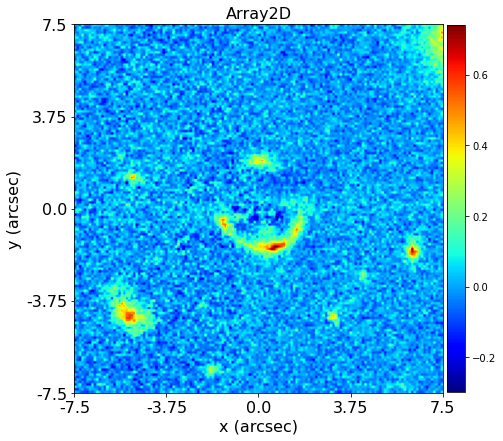

In [5]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=image)
array_plotter.figure_2d()

In [6]:
def noise_map_gen(img, scale=0.01):
    #image_without_zeros=img.clip(0.5*10**(-3))
    #noise_image = np.ones(len(img))*10**(0.5) # a list full of 10**(-2)
    noise_image = np.ones(len(img))
    N=10000
    for i in range(0, len(img)):
        #if img[i]>10**(-1): 
            #noise_image[i]=np.std(np.random.poisson(img[i], N)) # standard deviation
        noise_image[i]=0.5
    return al.Array2D.manual_slim(noise_image, pixel_scales=scale, shape_native=(150,150))

In [7]:
noise_map = noise_map_gen(image)

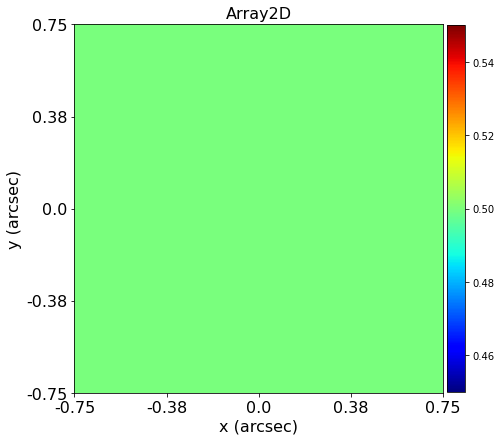

In [8]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=noise_map)
array_plotter.figure_2d()

In [9]:
psf = al.Kernel2D.from_fits(
    file_path=imgblocks_paths+psf_img_name, hdu=0, pixel_scales=grid_scale
)

In [10]:
new_psf=psf.rescaled_with_odd_dimensions_from_rescale_factor(rescale_factor=1)

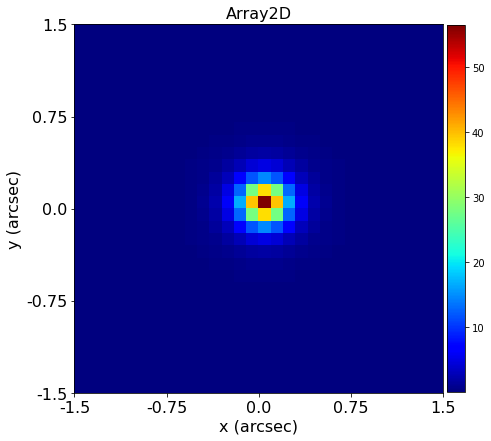

In [11]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=psf)
array_plotter.figure_2d()

In [12]:
imaging = al.Imaging(image=image, psf=new_psf, noise_map=noise_map)

In [13]:
mask = al.Mask2D.circular(
    shape_native=imaging.shape_native, pixel_scales=imaging.pixel_scales, radius=4.
)

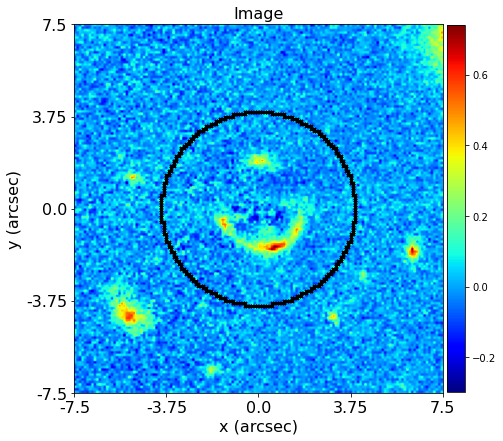

In [14]:
visuals_2d = aplt.Visuals2D(mask=mask)

imaging_plotter = aplt.ImagingPlotter(imaging=imaging, visuals_2d=visuals_2d)
imaging_plotter.figures_2d(image=True)

In [15]:
imaging = imaging.apply_mask(mask=mask)

In [16]:
lens_galaxy_model = af.Model(
    al.Galaxy,
    redshift=0.344,
    bulge=al.lp.EllDevVaucouleurs,
    mass=al.mp.EllIsothermal
)
source_galaxy_model = af.Model(al.Galaxy, redshift=1.0, disk=al.lp.EllExponential)


model = af.Collection(
    galaxies=af.Collection(lens=lens_galaxy_model, source=source_galaxy_model)
)

In [17]:
search = af.DynestyStatic(
    path_prefix="./",
    name="sys1_test",
    unique_tag="sys1_test",
    walks=5,
)

2021-08-04 16:36:09,402 - sys1_test - INFO - Creating search


In [18]:
analysis = al.AnalysisImaging(dataset=imaging)

In [19]:
result = search.fit(model=model, analysis=analysis)

2021-08-04 16:36:09,557 - sys1_test - INFO - Starting search
2021-08-04 16:36:09,565 - sys1_test - INFO - Saving path info
2021-08-04 16:36:09,629 - sys1_test - INFO - Not complete. Starting non-linear search.
2021-08-04 16:36:09,630 - sys1_test - INFO - number_of_cores == 1...
2021-08-04 16:36:09,631 - sys1_test - INFO - ...not using pool
2021-08-04 16:36:09,631 - autofit.non_linear.initializer - INFO - Generating initial samples of model, which are subject to prior limits and other constraints.
2021-08-04 16:36:10,506 - sys1_test - INFO - No Dynesty samples found, beginning new non-linear search. 


/home/joao/.local/lib/python3.8/site-packages/dynesty/dynesty.py:373: UserWarning: A note of caution: having `nlive < ndim * (ndim + 1) // 2` may result in unconstrained bounding distributions.
  warnings.warn("A note of caution: "
168it [00:22,  1.82it/s, bound: 0 | nc: 59 | ncall: 1685 | eff(%):  9.970 | loglstar:   -inf < -1227.214 <    inf | logz: -1231.012 +/-  4.994 | dlogz:  3.605 >  0.059]     /home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
181it [00:23,  8.96it/s, bound: 3 | nc: 5 | ncall: 1753 | eff(%): 10.325 | loglstar:   -inf < -1226.999 <    inf | logz: -1230.677 +/-  4.993 | dlogz:  3.025 >  0.059] /home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingl

2021-08-04 16:37:26,443 - sys1_test - INFO - 5000 Iterations: Performing update (Visualization, outputting samples, etc.).



512it [00:20, 18.40it/s, bound: 83 | nc: 54 | ncall: 6416 | eff(%):  7.980 | loglstar:   -inf < -1222.004 <    inf | logz: -1228.993 +/-  4.995 | dlogz:  3.571 >  0.059]  /home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
513it [00:24, 14.41it/s, bound: 84 | nc: 244 | ncall: 6660 | eff(%):  7.703 | loglstar:   -inf < -1221.986 <    inf | logz: -1228.993 +/-  4.995 | dlogz:  3.551 >  0.059]/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:216: UserWarning: Random number generation appears to be extremely inefficient. Adjusting the scale-factor accordingly.
  warnings.warn("Random number generation appears to be "
/home/joao/.local/lib/python3.8/site-packages/dynesty/sampling.py:238: UserWarning: Random walk proposals appear to be extremely inefficient. Adjusting the scale-factor a

2021-08-04 16:38:59,591 - sys1_test - INFO - 10000 Iterations: Performing update (Visualization, outputting samples, etc.).


...

2021-08-04 16:41:40,787 - sys1_test - INFO - 20000 Iterations: Performing update (Visualization, outputting samples, etc.).


1711it [00:00, 826589.97it/s, +50 | bound: 309 | nc: 1 | ncall: 17924 | eff(%):  9.825 | loglstar:   -inf < -1185.645 <    inf | logz: -1216.697 +/-  5.084 | dlogz:  0.001 >  0.059]


2021-08-04 16:41:58,612 - sys1_test - INFO - 25000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-08-04 16:42:15,976 - sys1_test - INFO - 30000 Iterations: Performing update (Visualization, outputting samples, etc.).


/home/joao/.local/lib/python3.8/site-packages/dynesty/plotting.py:245: UserWarning: Attempting to set identical bottom == top == 0.0 results in singular transformations; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


2021-08-04 16:42:59,892 - sys1_test - INFO - Removing zip file


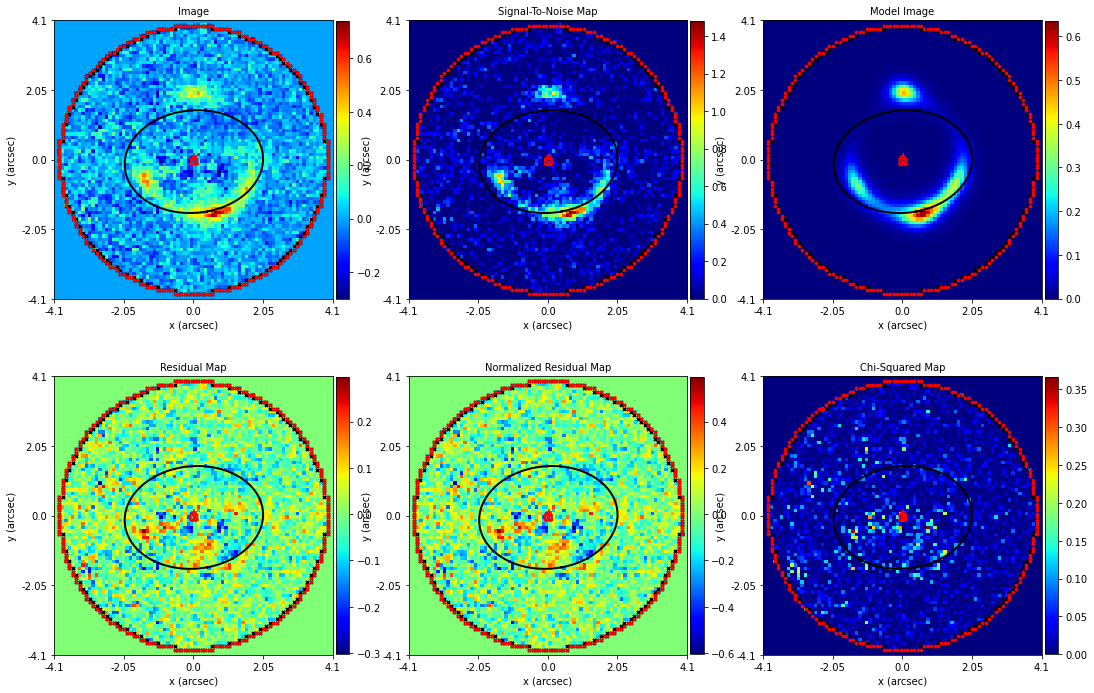

In [20]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()

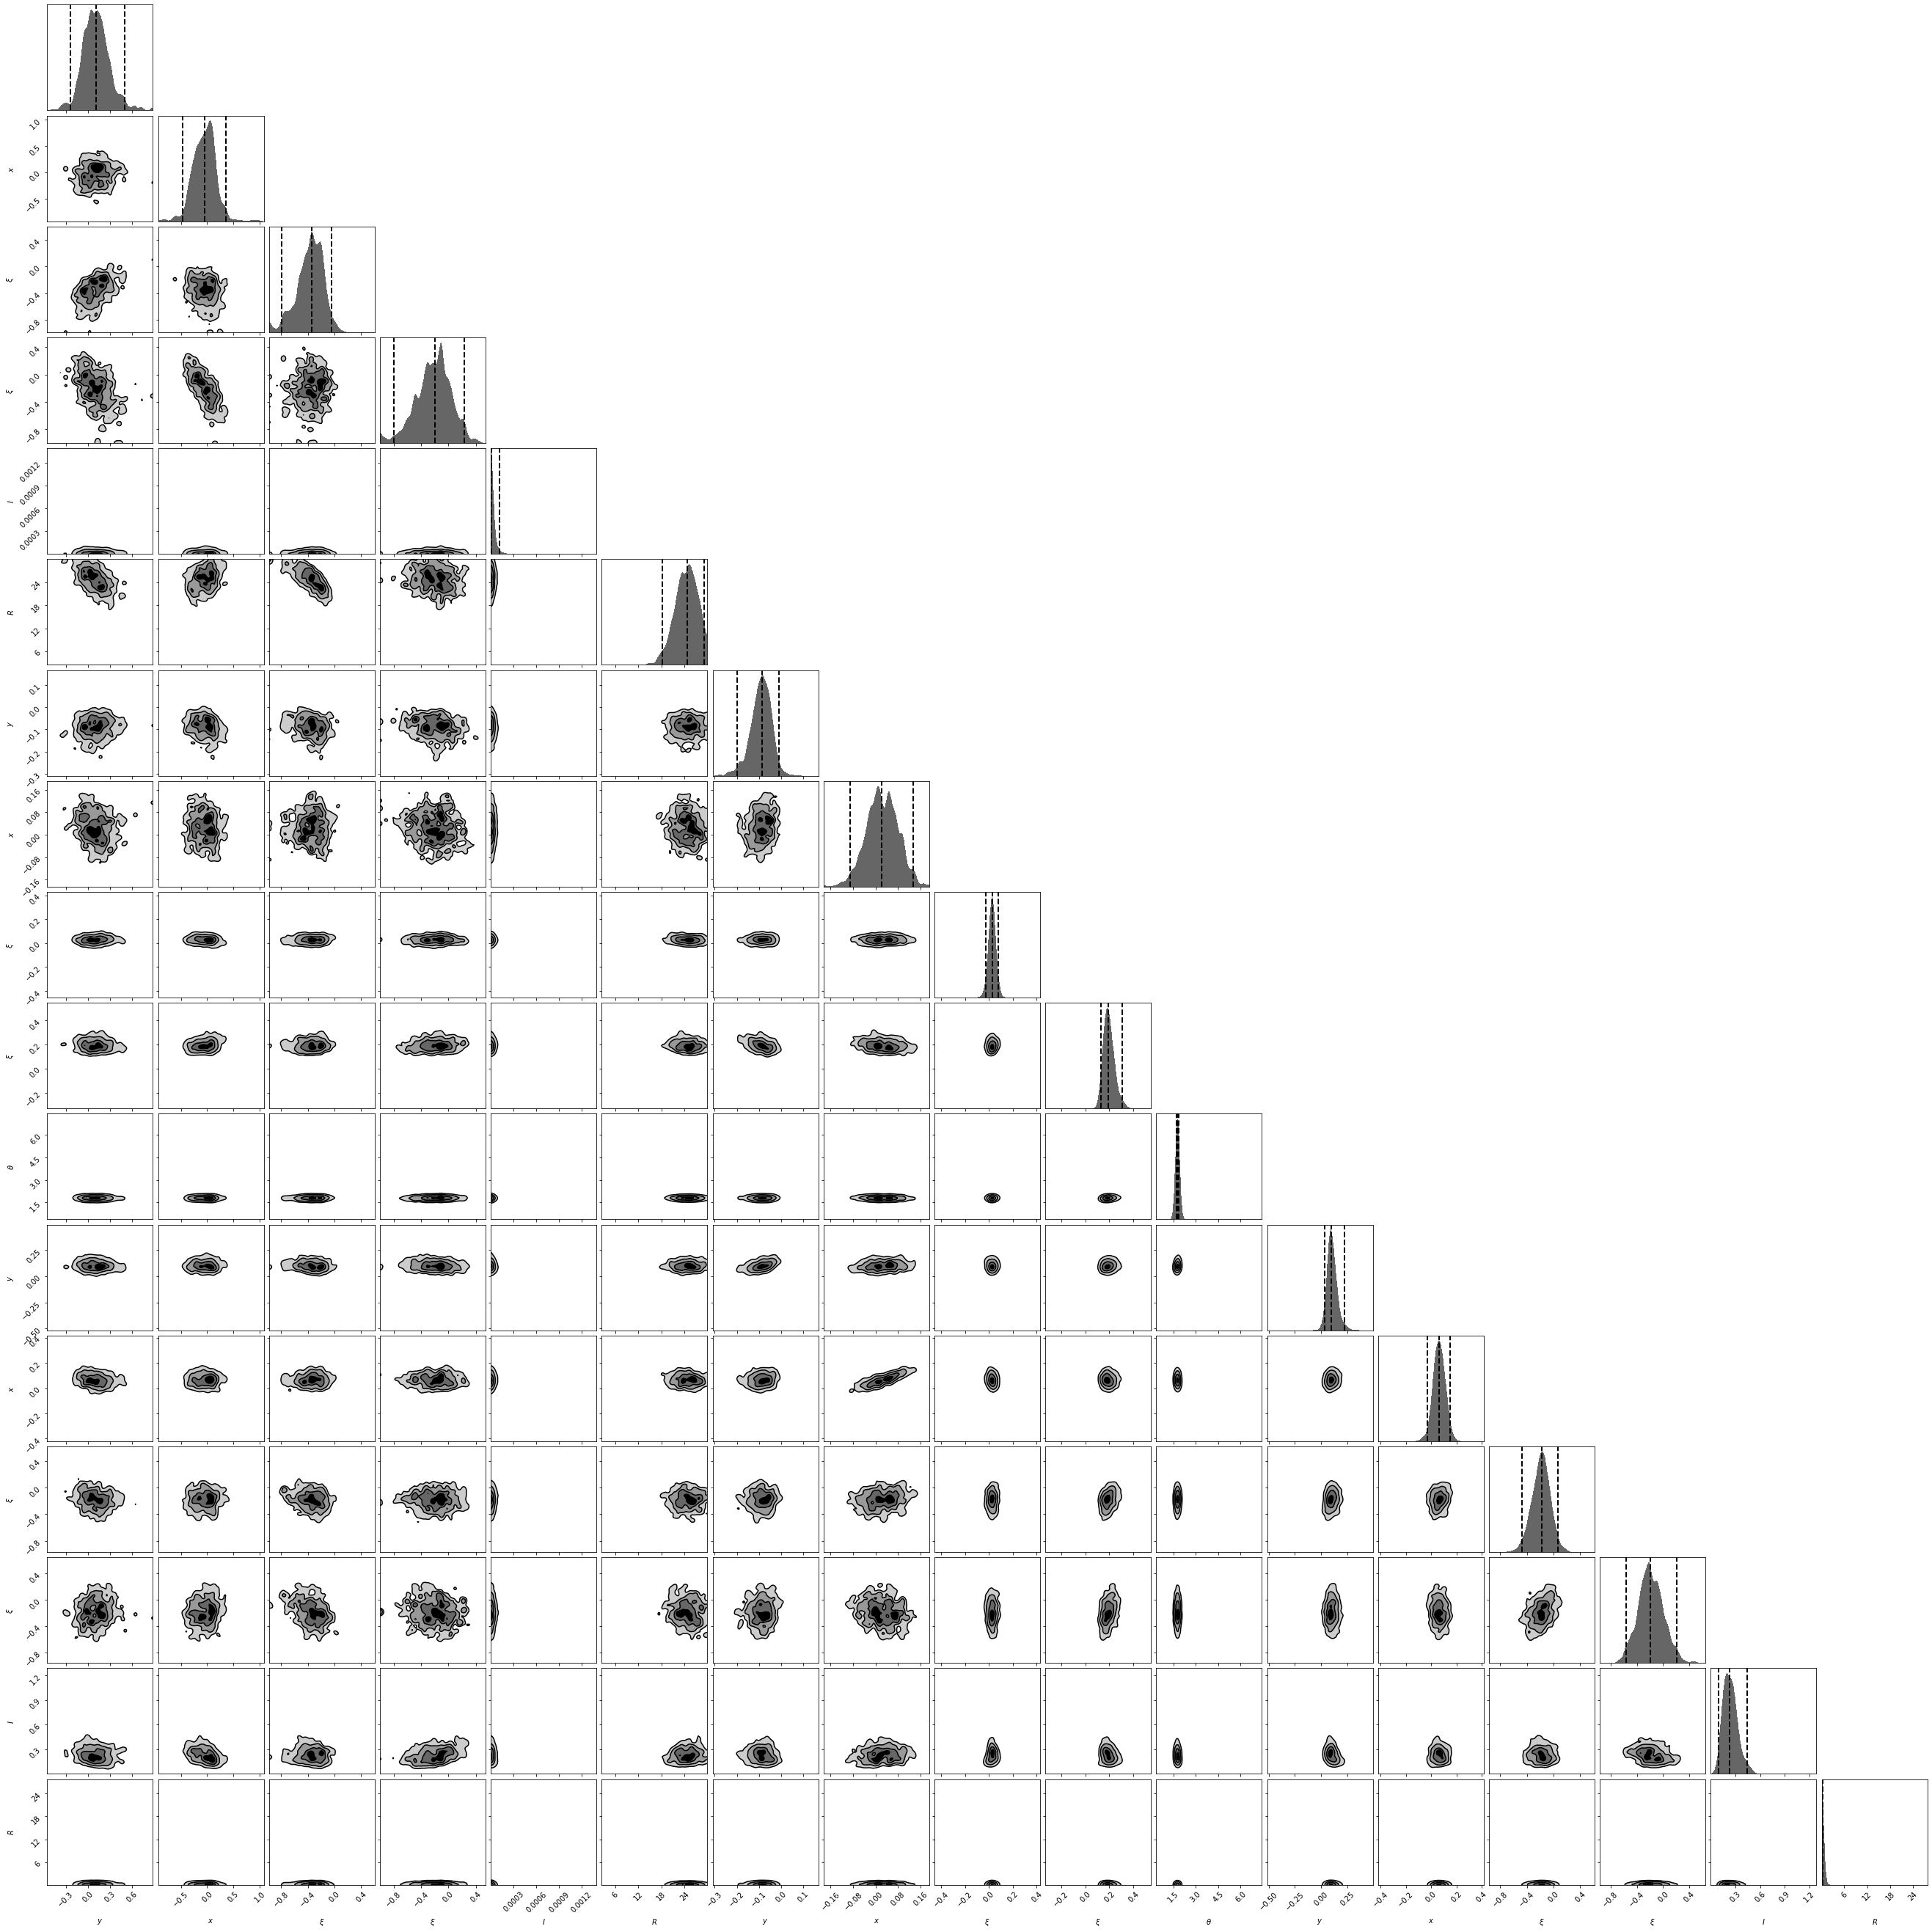

In [21]:
dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
dynesty_plotter.cornerplot()